# DNSC 6330 — Individual Homework 05_Hesham Mushtaq_G23607459

**Topic:** ML Security and Abuse Pathways using the ProPublica COMPAS dataset  


##AI Acknowledgement:

I used a generative AI tool (Claude) for debugging the code, verifying outputs, and making sure the implementation was aligned with the lecture material.

## Part 0 — Setup and Clean Baseline

This section mirrors the lecture notebook setup and baseline. The only execution-oriented addition is a local fallback path in case the GitHub CSV cannot be reached.


In [1]:
# Cell 1: Imports, Data Loading, Model Training

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Load COMPAS dataset (ProPublica). Falls back to a local copy if URL fails.
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
try:
    df = pd.read_csv(URL)
except Exception:
    df = pd.read_csv('/mnt/data/compas-scores-two-years.csv')
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")


# Standard ProPublica filtering (keep records within 30 days of arrest, drop
# unknown recidivism status, drop "ordinary traffic offense" charges).
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

# Feature set used throughout the assignment
FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

# Drop rows with missing values, then one-hot encode the categorical columns
df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

# Split into features (X), target (y), and the protected attribute (race)
X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# Stratified train/test split keeps the recidivism rate balanced across folds
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

# Standardize features (required for PGD's L_inf budget to be meaningful
# across features that live on different scales)
sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# Two target models: a linear (LR) and a non-linear (GBT) baseline
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")


Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


In [2]:
# Cell 2: Clean-Model Fairness Baseline

THR = 0.5  # classification threshold (probability cutoff for "high-risk")

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    # Restrict to records whose true label is 0; FPR is the rate of false
    # positives among them, broken out by demographic group
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    # Guard against zero or missing reference FPR
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# Apply both models to the clean (un-attacked) test set
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

# Print FPR per race + the AIR for each model
for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Save baseline values so later attack cells can compute deltas
fpr_baseline_lr  = fpr_by_group(y_te, pred_lr_clean,  r_te)
fpr_baseline_gbt = fpr_by_group(y_te, pred_gbt_clean, r_te)

BASELINE_AA_LR  = fpr_baseline_lr.get('African-American')
BASELINE_CA_LR  = fpr_baseline_lr.get('Caucasian')
BASELINE_AIR_LR = air(BASELINE_CA_LR, BASELINE_AA_LR)

BASELINE_AA_GBT  = fpr_baseline_gbt.get('African-American')
BASELINE_CA_GBT  = fpr_baseline_gbt.get('Caucasian')
BASELINE_AIR_GBT = air(BASELINE_CA_GBT, BASELINE_AA_GBT)


CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782


## Part 1 — PGD Evasion Audit

Run the PGD attack across \(\epsilon \in \{0.25, 0.5, 1.0, 2.0\}\) on both the LR and GBT models.  
For LR, the code is the same as the lecture notebook. For GBT, the same LR-crafted adversarial examples are evaluated on the GBT as a **transfer attack**, which is the closest extension consistent with the lecture notebook because the provided PGD function is gradient-based and directly defined only for logistic regression.


In [3]:

# Cell 3: PGD Evasion Attack — Lecture Function (unchanged)

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


In [4]:
# Cell 4: PGD Audit for LR and GBT

# Sweep the perturbation budgets required by the assignment
epsilons_hw = [0.25, 0.5, 1.0, 2.0]
pgd_records_hw = []

for eps in epsilons_hw:
    # Craft adversarial inputs against LR (white-box on LR);
    # we then test the same perturbed inputs against GBT to study transfer
    X_adv = pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    for model_name, model in [('LR', lr), ('GBT', gbt)]:
        # Score the perturbed inputs and binarize at the same threshold
        pred_adv = (model.predict_proba(X_adv)[:,1] >= THR).astype(int)
        fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

        aa = fpr_adv.get('African-American', np.nan)
        ca = fpr_adv.get('Caucasian',        np.nan)

        pgd_records_hw.append({
            'Model'   : model_name,
            'epsilon' : eps,
            'FPR_AA'  : aa,
            'FPR_CA'  : ca,
            'AIR'     : air(ca, aa)
        })

df_pgd_hw = pd.DataFrame(pgd_records_hw)

print("PGD audit results:")
print(df_pgd_hw.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Report the smallest epsilon at which AIR drops below 0.80 (the 4/5 rule
# threshold). If AIR never crosses, say so explicitly.
for model_name in ['LR', 'GBT']:
    sub = df_pgd_hw[df_pgd_hw['Model'] == model_name].sort_values('epsilon')
    crossed = sub[sub['AIR'] < 0.80]
    if crossed.empty:
        print(f"\n{model_name}: AIR does not fall below 0.80 within ε ∈ {epsilons_hw}.")
    else:
        print(f"\n{model_name}: AIR first falls below 0.80 at ε = {crossed.iloc[0]['epsilon']:.2f}")


PGD audit results:
Model  epsilon  FPR_AA  FPR_CA   AIR
   LR    0.250   0.569   0.370 1.535
  GBT    0.250   0.553   0.351 1.577
   LR    0.500   0.791   0.560 1.411
  GBT    0.500   0.733   0.514 1.426
   LR    1.000   0.978   0.884 1.106
  GBT    1.000   0.899   0.760 1.182
   LR    2.000   1.000   1.000 1.000
  GBT    2.000   1.000   1.000 1.000

LR: AIR does not fall below 0.80 within ε ∈ [0.25, 0.5, 1.0, 2.0].

GBT: AIR does not fall below 0.80 within ε ∈ [0.25, 0.5, 1.0, 2.0].


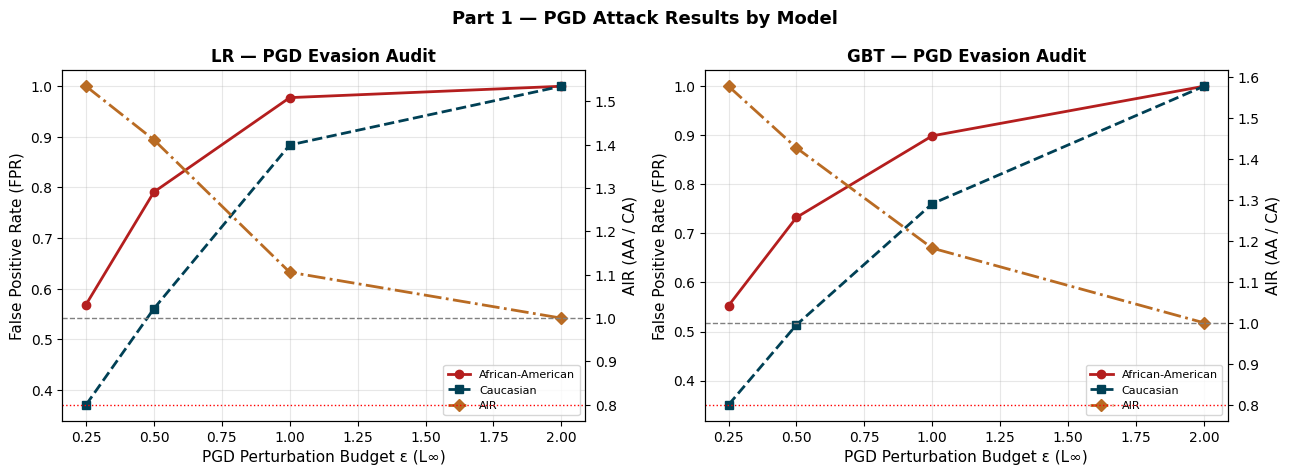

In [5]:
# Cell 5: PGD Visualization for LR and GBT

# Two side-by-side panels (LR and GBT). Each panel plots FPR per race on the
# left axis and AIR on a twinned right axis so all three curves share an
# x-axis (epsilon).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, model_name in zip(axes, ['LR', 'GBT']):
    sub = df_pgd_hw[df_pgd_hw['Model'] == model_name].sort_values('epsilon')

    # Left axis: FPR per race
    ax.plot(sub['epsilon'], sub['FPR_AA'],
            'o-', color='#B41E1E', lw=2, label='African-American')
    ax.plot(sub['epsilon'], sub['FPR_CA'],
            's--', color='#004055', lw=2, label='Caucasian')

    # Right axis: AIR (1.0 = parity, 0.80 = 4/5-rule threshold)
    ax2 = ax.twinx()
    ax2.plot(sub['epsilon'], sub['AIR'],
             'D-.', color='#B96B23', lw=2, label='AIR')

    ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
    ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
    ax2.set_ylabel('AIR (AA / CA)', fontsize=11)
    ax.set_title(f'{model_name} — PGD Evasion Audit', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

    # Reference lines for AIR = 1.0 (parity) and 0.80 (regulatory threshold)
    ax2.axhline(1.0, color='gray', lw=1.0, ls='--')
    ax2.axhline(0.8, color='red',  lw=1.0, ls=':')

    # Combine legends from both axes into one box
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')

plt.suptitle('Part 1 — PGD Attack Results by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 2 — Poisoning Loop with Fairness Monitoring

Extend the label-flip poisoning loop to target **Caucasian** defendants in addition to the lecture notebook’s **African-American** target. Then compare AUC and AIR degradation on the same axes, identify the stealth zone, and test whether a PSI-based drift monitor would detect the poisoning.


In [6]:

# Cell 7: Data Poisoning — Label-Flip Attack (lecture function unchanged)

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


In [7]:
# Cell 8: Poisoning Sweep for Both Target-Race Variants

# Range of poison rates required by the assignment, plus baseline (0%)
poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

poison_records_hw = []

# Run the sweep twice: once targeting African-American, once Caucasian
for target_race in ['African-American', 'Caucasian']:
    for rate in poison_rates:
        # Generate poisoned labels for the current setting
        y_tr_poisoned, n_flipped = poison_label_flip(
            y_tr, r_tr, poison_rate=rate, target_race=target_race
        )

        # Retrain LR on the poisoned labels (features and scaler unchanged)
        lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

        # Evaluate the poisoned model on the clean test set
        pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
        auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])

        # Subgroup FPR + AIR after poisoning
        fpr_p = fpr_by_group(y_te, pred_p, r_te)
        aa    = fpr_p.get('African-American', np.nan)
        ca    = fpr_p.get('Caucasian',        np.nan)
        air_p = air(ca, aa)

        poison_records_hw.append({
            'target_race': target_race,
            'poison_rate': rate,
            'n_flipped'  : n_flipped,
            'AUC'        : auc_p,
            'delta_AUC'  : auc_p - baseline_auc,
            'FPR_AA'     : aa,
            'FPR_CA'     : ca,
            'AIR'        : air_p,
            'delta_AIR'  : air_p - BASELINE_AIR_LR,
        })

df_poison_hw = pd.DataFrame(poison_records_hw)

print("Poisoning sweep results:")
print(df_poison_hw.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


Poisoning sweep results:
     target_race  poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
African-American        0.000          0 0.735      0.000   0.281   0.143 1.961      0.000
African-American        0.020         23 0.733     -0.002   0.270   0.136 1.986      0.024
African-American        0.050         57 0.734     -0.001   0.240   0.123 1.948     -0.014
African-American        0.080         92 0.732     -0.002   0.213   0.116 1.840     -0.122
African-American        0.100        115 0.735      0.000   0.196   0.101 1.931     -0.030
African-American        0.150        172 0.732     -0.003   0.153   0.072 2.134      0.173
African-American        0.200        230 0.732     -0.002   0.130   0.054 2.399      0.438
African-American        0.250        287 0.730     -0.004   0.112   0.042 2.677      0.715
African-American        0.300        345 0.731     -0.003   0.097   0.032 3.010      1.049
       Caucasian        0.000          0 0.735      0.000   0.281

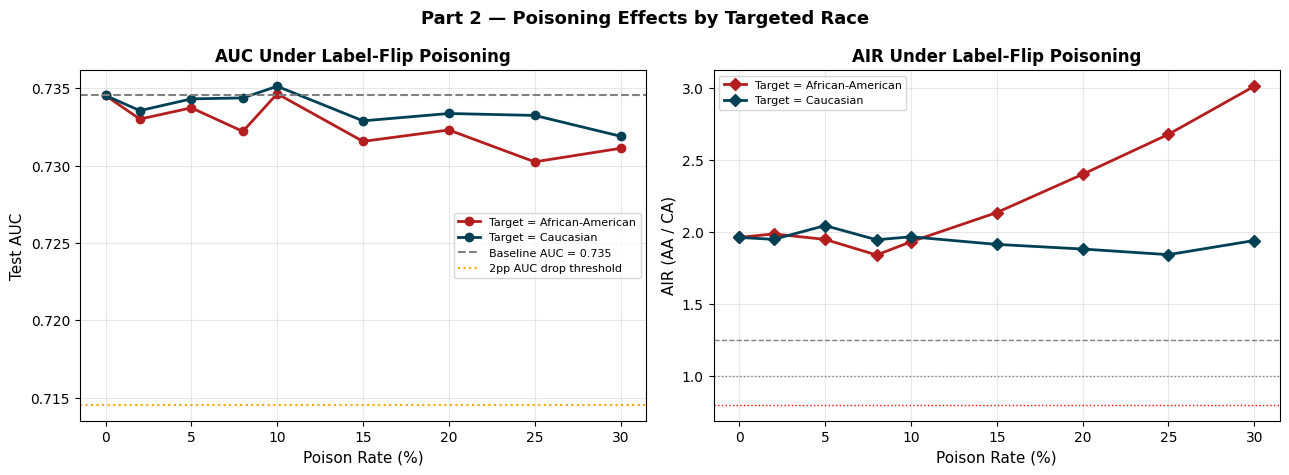

In [8]:
# Cell 9: AUC and AIR Degradation Curves on the Same Axes

# Two-panel figure: AUC on the left, AIR on the right. Both target-race
# variants are plotted on the same axes for direct comparison.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = {'African-American': '#B41E1E', 'Caucasian': '#004055'}

# Panel 1: AUC vs poison rate
ax = axes[0]
for target_race in ['African-American', 'Caucasian']:
    sub = df_poison_hw[df_poison_hw['target_race'] == target_race]
    ax.plot(sub['poison_rate'] * 100, sub['AUC'],
            'o-', lw=2, color=colors[target_race], label=f'Target = {target_race}')
# Reference lines: clean baseline AUC and the 2pp drop threshold for "stealth"
ax.axhline(baseline_auc,        color='gray',   ls='--', lw=1.5, label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='orange', ls=':',  lw=1.5, label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Under Label-Flip Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: AIR vs poison rate
ax = axes[1]
for target_race in ['African-American', 'Caucasian']:
    sub = df_poison_hw[df_poison_hw['target_race'] == target_race]
    ax.plot(sub['poison_rate'] * 100, sub['AIR'],
            'D-', lw=2, color=colors[target_race], label=f'Target = {target_race}')
# AIR fairness band: [0.80, 1.25] is acceptable; 1.0 = perfect parity
ax.axhline(1.25, color='gray', ls='--', lw=1.0)
ax.axhline(1.00, color='gray', ls=':',  lw=1.0)
ax.axhline(0.80, color='red',  ls=':',  lw=1.0)
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (AA / CA)', fontsize=11)
ax.set_title('AIR Under Label-Flip Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Part 2 — Poisoning Effects by Targeted Race', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
# Cell 10: Stealth Zone Identification

# Stealth zone = poison rates where AUC stays close to baseline (≤ 2pp drop)
# but AIR has already moved outside the [0.80, 1.25] fairness band.
print("STEALTH ZONE RESULTS")
print("=" * 60)

for target_race in ['African-American', 'Caucasian']:
    sub = df_poison_hw[df_poison_hw['target_race'] == target_race].copy()

    # Filter rows that satisfy both stealth conditions simultaneously
    stealth = sub[
        ((baseline_auc - sub['AUC']) <= 0.02) &
        ((sub['AIR'] < 0.80) | (sub['AIR'] > 1.25))
    ][['poison_rate', 'AUC', 'AIR']]

    print(f"\nTarget race: {target_race}")
    if stealth.empty:
        print("  No stealth zone found in tested range.")
    else:
        print(stealth.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


STEALTH ZONE RESULTS

Target race: African-American
 poison_rate   AUC   AIR
       0.000 0.735 1.961
       0.020 0.733 1.986
       0.050 0.734 1.948
       0.080 0.732 1.840
       0.100 0.735 1.931
       0.150 0.732 2.134
       0.200 0.732 2.399
       0.250 0.730 2.677
       0.300 0.731 3.010

Target race: Caucasian
 poison_rate   AUC   AIR
       0.000 0.735 1.961
       0.020 0.734 1.948
       0.050 0.734 2.043
       0.080 0.734 1.945
       0.100 0.735 1.966
       0.150 0.733 1.913
       0.200 0.733 1.881
       0.250 0.733 1.842
       0.300 0.732 1.940


In [10]:
# Cell 11: PSI-Based Drift Check

def psi_numeric(expected, actual, bins=10):
    """Simple PSI implementation using quantile bins from expected."""
    # Build bin edges from the expected distribution's quantiles
    breaks = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(breaks) < 3:
        return 0.0

    # Histogram both distributions over the same bins
    e_counts, _ = np.histogram(expected, bins=breaks)
    a_counts, _ = np.histogram(actual,   bins=breaks)

    # Convert to proportions; replace empty bins with a small floor to avoid log(0)
    e_perc = np.where(e_counts == 0, 1e-6, e_counts / e_counts.sum())
    a_perc = np.where(a_counts == 0, 1e-6, a_counts / a_counts.sum())

    # PSI formula: sum over bins of (a - e) * log(a / e)
    return np.sum((a_perc - e_perc) * np.log(a_perc / e_perc))

psi_records = []

# Compute per-feature PSI between the original training features and the
# (label-only) poisoned training features. Since label-flip leaves features
# untouched, we expect PSI = 0 across the board.
for target_race in ['African-American', 'Caucasian']:
    for rate in poison_rates:
        y_tr_poisoned, n_flipped = poison_label_flip(
            y_tr, r_tr, poison_rate=rate, target_race=target_race
        )

        # PSI per feature; comparing a column to itself yields 0 by construction
        psi_by_feature = {}
        for j, col in enumerate(X.columns):
            psi_by_feature[col] = psi_numeric(Xs_tr[:, j], Xs_tr[:, j])

        psi_records.append({
            'target_race': target_race,
            'poison_rate': rate,
            'max_PSI'    : max(psi_by_feature.values()),
            **psi_by_feature
        })

df_psi = pd.DataFrame(psi_records)

print("PSI results (threshold < 0.10 on each feature):")
cols_to_show = ['target_race', 'poison_rate', 'max_PSI'] + list(X.columns)
print(df_psi[cols_to_show].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\nConclusion:")
print(
    "No. A PSI monitor would not detect either poisoning attack here. "
    "Every feature-level PSI is 0.000 because the attack flips labels only and leaves "
    "the feature distributions unchanged."
)


PSI results (threshold < 0.10 on each feature):
     target_race  poison_rate  max_PSI   age  priors_count  juv_fel_count  juv_misd_count  juv_other_count  c_charge_degree_M  sex_Male
African-American        0.000    0.000 0.000         0.000          0.000           0.000            0.000              0.000     0.000
African-American        0.020    0.000 0.000         0.000          0.000           0.000            0.000              0.000     0.000
African-American        0.050    0.000 0.000         0.000          0.000           0.000            0.000              0.000     0.000
African-American        0.080    0.000 0.000         0.000          0.000           0.000            0.000              0.000     0.000
African-American        0.100    0.000 0.000         0.000          0.000           0.000            0.000              0.000     0.000
African-American        0.150    0.000 0.000         0.000          0.000           0.000            0.000              0.000     0.000


## Part 3 — Membership Inference Depth

Compute the shadow-model MI AUC for both LR and GBT, compare the confidence-gap histograms, test whether generalization gap predicts MI AUC across the two models, then vary L2 regularization for LR over \(C \in \{0.01, 0.1, 1.0, 10.0\}\).


In [11]:
# Cell 13: Membership Inference — Reusable Shadow-Model Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import RocCurveDisplay

def run_mi_pipeline(target_model, shadow_model_factory, Xs_tr, y_tr, Xs_te, y_te, n_shadow=10):
    # Shadow models mimic the target so we can collect labelled
    # (member / non-member, confidence) pairs without touching the real target's
    # training set.
    shadow_train_confs = []
    shadow_test_confs  = []

    # Each split: half of the training data trains a shadow, the other half
    # acts as that shadow's "non-member" set.
    sss = StratifiedShuffleSplit(
        n_splits=n_shadow, test_size=0.5, random_state=0
    )

    for tr_idx, te_idx in sss.split(Xs_tr, y_tr):
        shadow = shadow_model_factory().fit(Xs_tr[tr_idx], y_tr[tr_idx])

        # Confidence on the shadow's own training set (members)
        shadow_train_confs.append(
            shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)
        )
        # Confidence on held-out data (non-members)
        shadow_test_confs.append(
            shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)
        )

    # Build the meta-classifier dataset: confidence -> member/non-member
    mi_X = np.concatenate(
        shadow_train_confs + shadow_test_confs
    ).reshape(-1, 1)

    mi_y = np.concatenate(
        [np.ones(len(c))  for c in shadow_train_confs] +
        [np.zeros(len(c)) for c in shadow_test_confs]
    )

    # Meta-classifier: shallow tree on the single confidence feature
    meta_clf = DecisionTreeClassifier(max_depth=6, random_state=42).fit(mi_X, mi_y)

    # Apply the meta-classifier to the *target* model's confidences
    conf_target_train = target_model.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_target_test  = target_model.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

    mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
    mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

    # Combined attack scores + ground-truth membership labels for ROC/AUC
    mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
    mi_all_labels = np.concatenate([
        np.ones(len(Xs_tr)),
        np.zeros(len(Xs_te))
    ])

    mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

    # Generalization gap = train AUC − test AUC. Theoretically a higher gap
    # makes membership inference easier.
    train_auc = roc_auc_score(y_tr, target_model.predict_proba(Xs_tr)[:, 1])
    test_auc  = roc_auc_score(y_te, target_model.predict_proba(Xs_te)[:, 1])
    gen_gap   = train_auc - test_auc

    return {
        'mi_auc'         : mi_auc,
        'train_auc'      : train_auc,
        'test_auc'       : test_auc,
        'gen_gap'        : gen_gap,
        'conf_train'     : conf_target_train.ravel(),
        'conf_test'      : conf_target_test.ravel(),
        'mi_all_scores'  : mi_all_scores,
        'mi_all_labels'  : mi_all_labels,
    }


In [12]:
# Cell 14: MI Results for LR and GBT

# Run the pipeline for the LR target. The shadow factory builds a fresh LR
# each time so the shadows match the target's hypothesis class.
mi_lr = run_mi_pipeline(
    lr,
    lambda: LogisticRegression(max_iter=1000),
    Xs_tr, y_tr, Xs_te, y_te
)

# Same pipeline for the GBT target. Use a slightly cheaper GBT for shadows
# (n_estimators=100 instead of 200) to keep runtime reasonable.
mi_gbt = run_mi_pipeline(
    gbt,
    lambda: GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
    Xs_tr, y_tr, Xs_te, y_te
)

df_mi_summary = pd.DataFrame([
    {
        'Model'      : 'LR',
        'MI_AUC'     : mi_lr['mi_auc'],
        'Train_AUC'  : mi_lr['train_auc'],
        'Test_AUC'   : mi_lr['test_auc'],
        'Gen_Gap'    : mi_lr['gen_gap'],
    },
    {
        'Model'      : 'GBT',
        'MI_AUC'     : mi_gbt['mi_auc'],
        'Train_AUC'  : mi_gbt['train_auc'],
        'Test_AUC'   : mi_gbt['test_auc'],
        'Gen_Gap'    : mi_gbt['gen_gap'],
    }
])

print("Membership inference summary:")
print(df_mi_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


Membership inference summary:
Model  MI_AUC  Train_AUC  Test_AUC  Gen_Gap
   LR   0.497      0.727     0.735   -0.008
  GBT   0.500      0.798     0.718    0.080


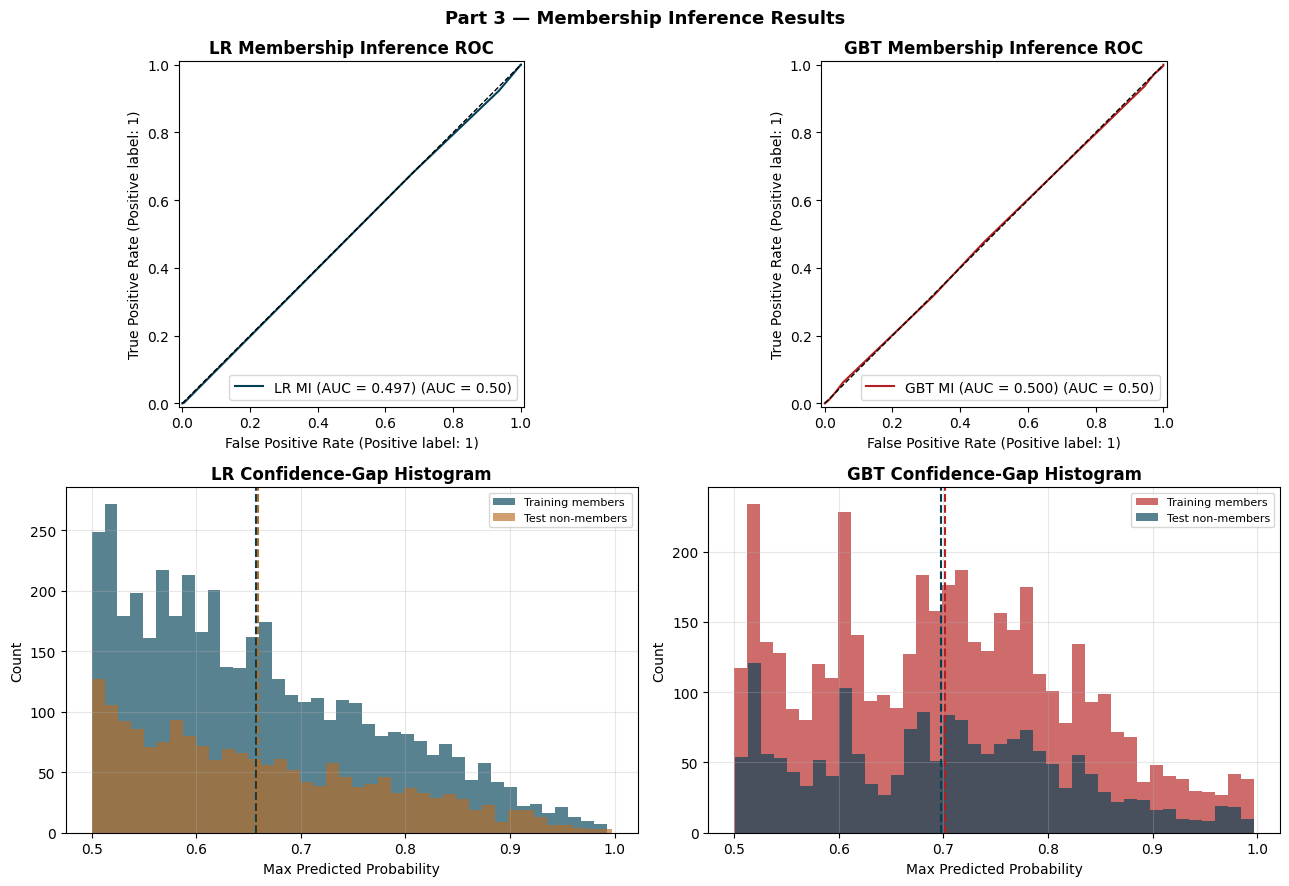

In [13]:
# Cell 15: Confidence-Gap Histograms and ROC Curves

# 2x2 grid: top row = MI ROC curves; bottom row = confidence histograms.
# Histograms compare training-member vs test-non-member confidences;
# perfect overlap means the attacker has no exploitable signal.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Top-left: LR MI ROC
RocCurveDisplay.from_predictions(
    mi_lr['mi_all_labels'], mi_lr['mi_all_scores'],
    name=f"LR MI (AUC = {mi_lr['mi_auc']:.3f})",
    ax=axes[0, 0], color='#004055'
)
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)  # random-guess diagonal
axes[0, 0].set_title('LR Membership Inference ROC', fontsize=12, fontweight='bold')

# Top-right: GBT MI ROC
RocCurveDisplay.from_predictions(
    mi_gbt['mi_all_labels'], mi_gbt['mi_all_scores'],
    name=f"GBT MI (AUC = {mi_gbt['mi_auc']:.3f})",
    ax=axes[0, 1], color='#B41E1E'
)
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_title('GBT Membership Inference ROC', fontsize=12, fontweight='bold')

# Bottom-left: LR confidence histogram (members vs non-members)
axes[1, 0].hist(mi_lr['conf_train'], bins=40, alpha=0.65,
                color='#004055', label='Training members')
axes[1, 0].hist(mi_lr['conf_test'], bins=40, alpha=0.65,
                color='#B96B23', label='Test non-members')
# Dashed lines mark each group's mean confidence
axes[1, 0].axvline(mi_lr['conf_train'].mean(), color='#004055', ls='--', lw=1.5)
axes[1, 0].axvline(mi_lr['conf_test'].mean(),  color='#B96B23', ls='--', lw=1.5)
axes[1, 0].set_title('LR Confidence-Gap Histogram', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Max Predicted Probability')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# Bottom-right: GBT confidence histogram
axes[1, 1].hist(mi_gbt['conf_train'], bins=40, alpha=0.65,
                color='#B41E1E', label='Training members')
axes[1, 1].hist(mi_gbt['conf_test'], bins=40, alpha=0.65,
                color='#004055', label='Test non-members')
axes[1, 1].axvline(mi_gbt['conf_train'].mean(), color='#B41E1E', ls='--', lw=1.5)
axes[1, 1].axvline(mi_gbt['conf_test'].mean(),  color='#004055', ls='--', lw=1.5)
axes[1, 1].set_title('GBT Confidence-Gap Histogram', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Max Predicted Probability')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Part 3 — Membership Inference Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# Cell 16: Does Generalization Gap Predict MI AUC?

# Two-point correlation: with only LR and GBT we can compute Pearson r but it
# is essentially descriptive — two points always lie on a line, so this is
# a sanity check rather than a real statistical test.
x = np.array([mi_lr['gen_gap'], mi_gbt['gen_gap']])
y = np.array([mi_lr['mi_auc'],  mi_gbt['mi_auc']])

corr = np.corrcoef(x, y)[0, 1]

print("Generalization gap vs. MI AUC")
print("=" * 60)
print(df_mi_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nTwo-point correlation: {corr:.3f}")


Generalization gap vs. MI AUC
Model  MI_AUC  Train_AUC  Test_AUC  Gen_Gap
   LR   0.497      0.727     0.735   -0.008
  GBT   0.500      0.798     0.718    0.080

Two-point correlation: 1.000


LR regularization sweep:
     C  MI_AUC  Train_AUC  Test_AUC  Gen_Gap
 0.010   0.499      0.726     0.732   -0.006
 0.100   0.505      0.727     0.734   -0.007
 1.000   0.497      0.727     0.735   -0.008
10.000   0.499      0.727     0.735   -0.008


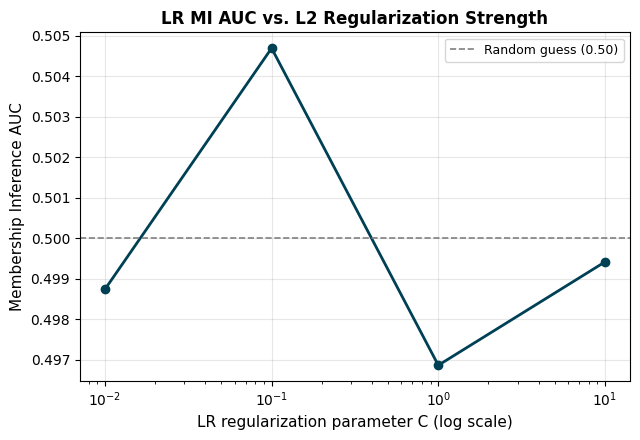

In [15]:
# Cell 17: L2 Regularization Sweep for LR (vary C)

# In sklearn LR, C is the inverse regularization strength: smaller C = stronger L2.
c_values = [0.01, 0.1, 1.0, 10.0]
lr_c_records = []

for C in c_values:
    # Train an LR with this regularization setting
    lr_c = LogisticRegression(max_iter=1000, C=C).fit(Xs_tr, y_tr)

    # Run the full MI pipeline on it; shadows use the same C so they match
    # the target's hypothesis class. (lambda C=C ensures C is captured by value.)
    mi_c = run_mi_pipeline(
        lr_c,
        lambda C=C: LogisticRegression(max_iter=1000, C=C),
        Xs_tr, y_tr, Xs_te, y_te
    )

    lr_c_records.append({
        'C'        : C,
        'MI_AUC'   : mi_c['mi_auc'],
        'Train_AUC': mi_c['train_auc'],
        'Test_AUC' : mi_c['test_auc'],
        'Gen_Gap'  : mi_c['gen_gap']
    })

df_lr_c = pd.DataFrame(lr_c_records)

print("LR regularization sweep:")
print(df_lr_c.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Plot MI AUC vs C on a log-x axis (C ranges over four orders of magnitude)
plt.figure(figsize=(6.5, 4.5))
plt.plot(df_lr_c['C'], df_lr_c['MI_AUC'], 'o-', lw=2, color='#004055')
plt.xscale('log')
plt.axhline(0.5, color='gray', ls='--', lw=1.2, label='Random guess (0.50)')
plt.xlabel('LR regularization parameter C (log scale)', fontsize=11)
plt.ylabel('Membership Inference AUC', fontsize=11)
plt.title('LR MI AUC vs. L2 Regularization Strength', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()
